imageio-ffmpeg path: C:\Users\Jonah\anaconda3\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe
Matplotlib sees FFmpeg: True

Running nominal MPC simulation...
MPC step 10/180
MPC step 20/180
MPC step 30/180
MPC step 40/180
MPC step 50/180
MPC step 60/180
MPC step 70/180
MPC step 80/180
MPC step 90/180
MPC step 100/180
MPC step 110/180
MPC step 120/180
MPC step 130/180

Engine cutoff at t = 134.0 s for MPC

Running nominal PD simulation...
PD step 10/180
PD step 20/180
PD step 30/180
PD step 40/180
PD step 50/180
PD step 60/180
PD step 70/180
PD step 80/180
PD step 90/180
PD step 100/180
PD step 110/180
PD step 120/180
PD step 130/180
PD step 140/180
PD step 150/180
PD step 160/180
PD step 170/180
PD step 180/180

Running wind-disturbed MPC simulation...
MPC step 10/180
MPC step 20/180
MPC step 30/180
MPC step 40/180
MPC step 50/180
MPC step 60/180
MPC step 70/180
MPC step 80/180
MPC step 90/180
MPC step 100/180
MPC step 110/180
MPC step 120/180
MPC step 130/180
MPC 

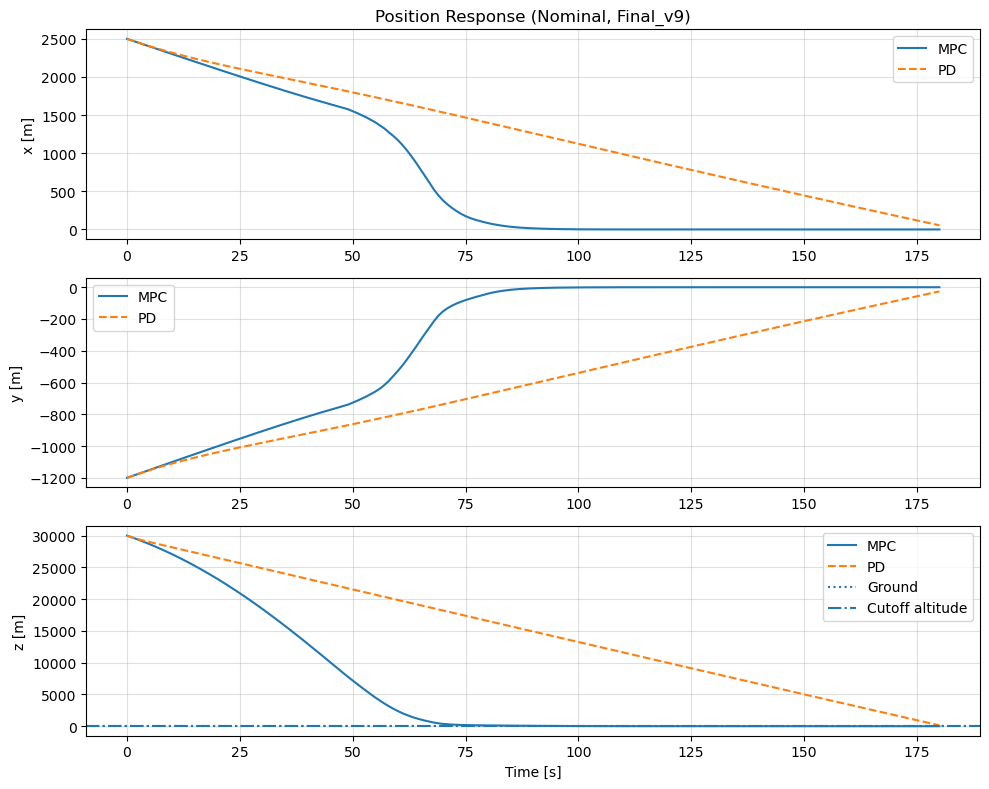

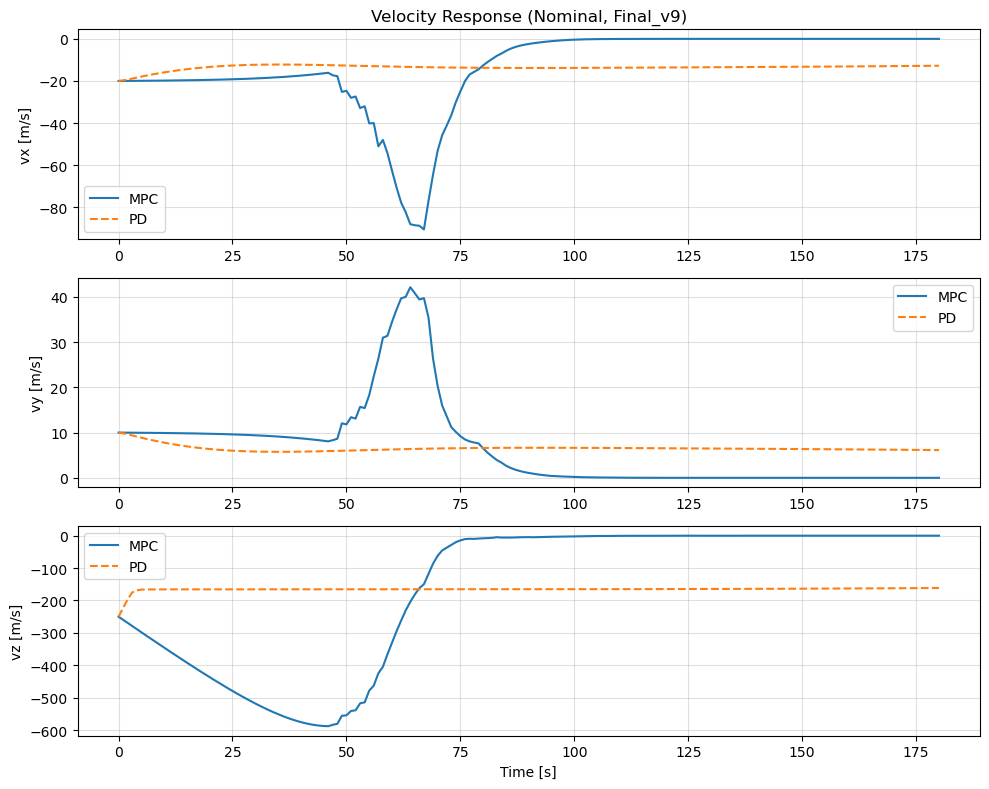

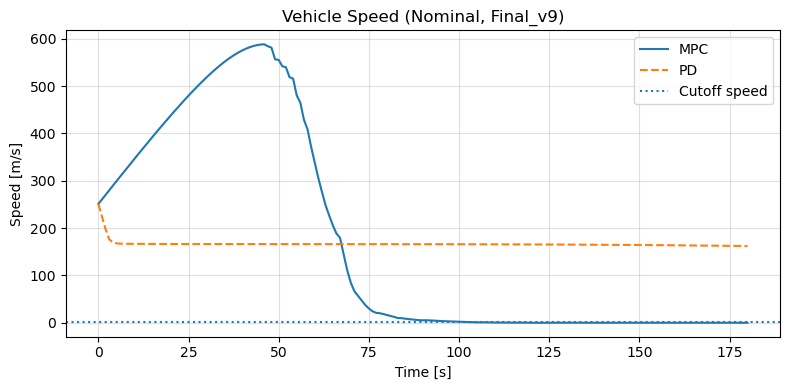

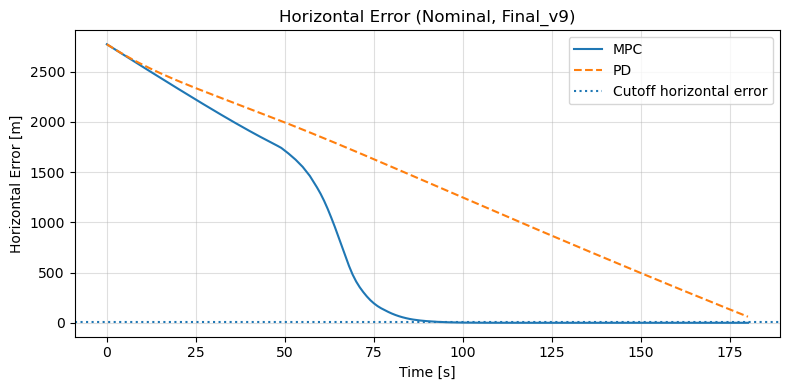

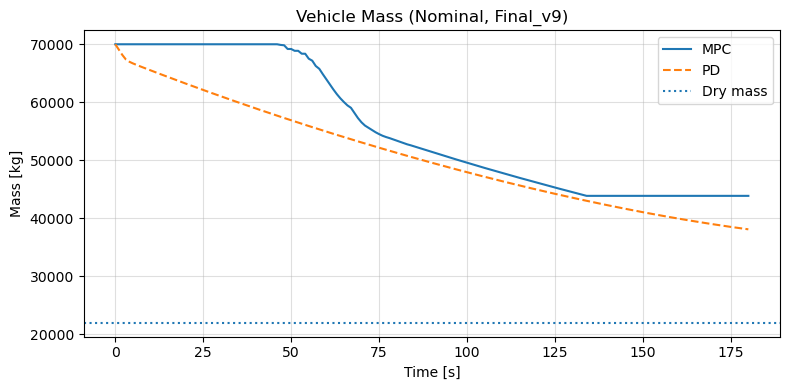

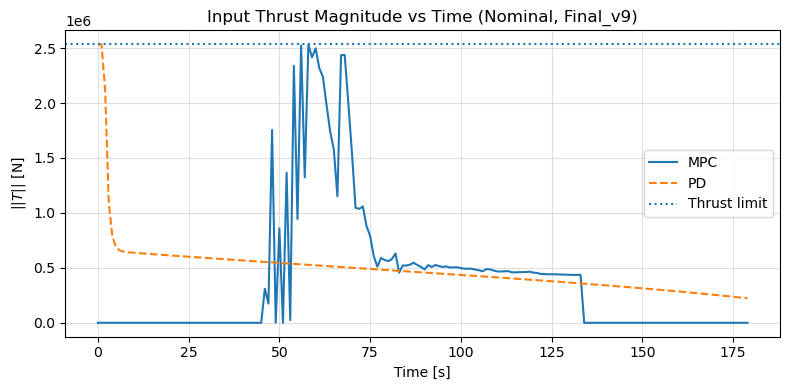

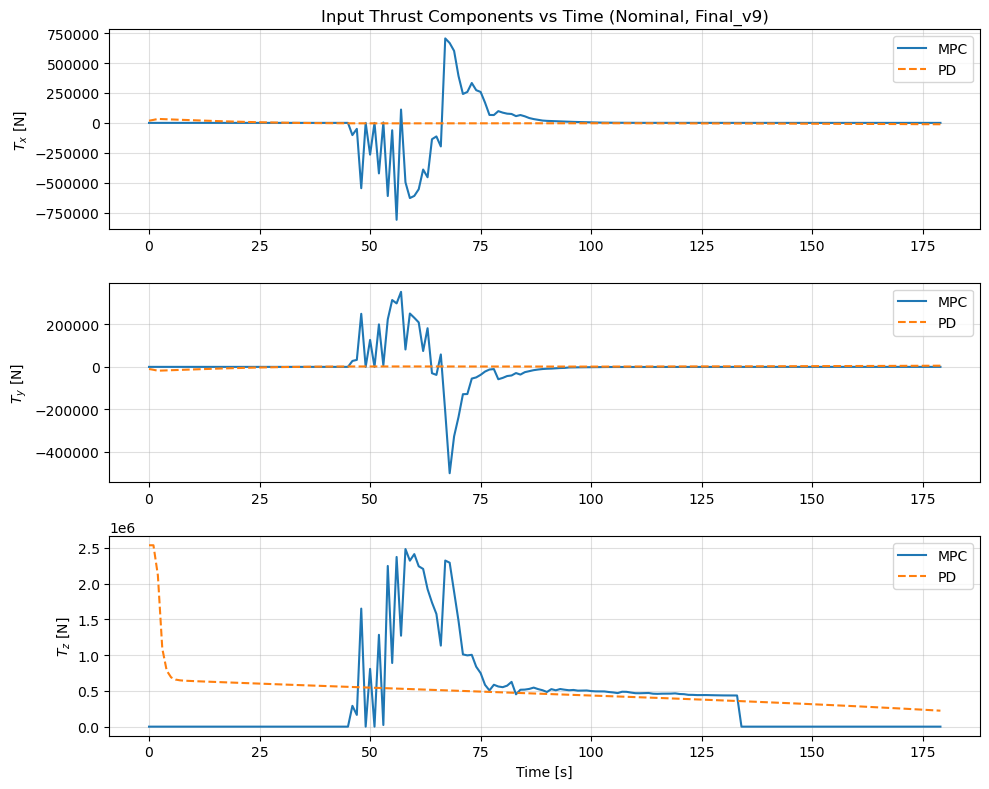

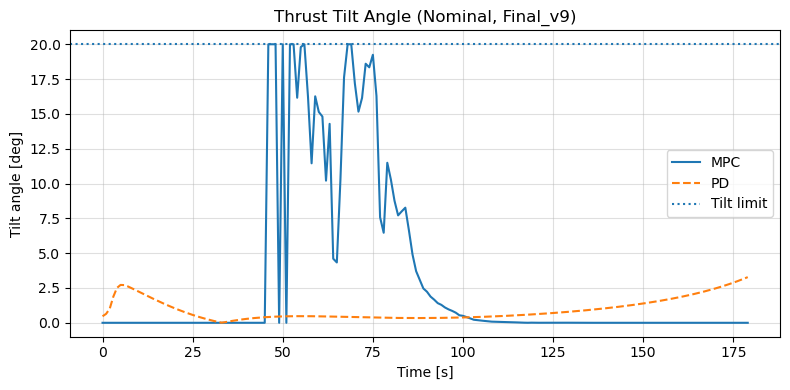

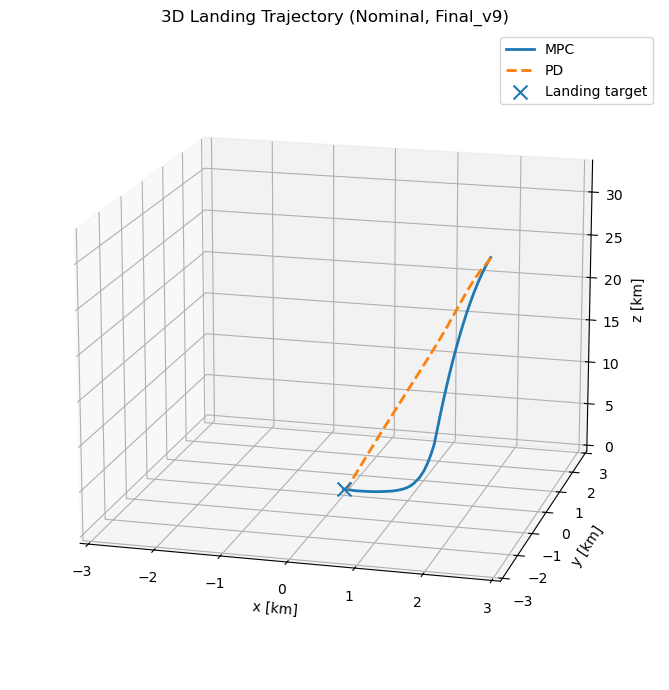

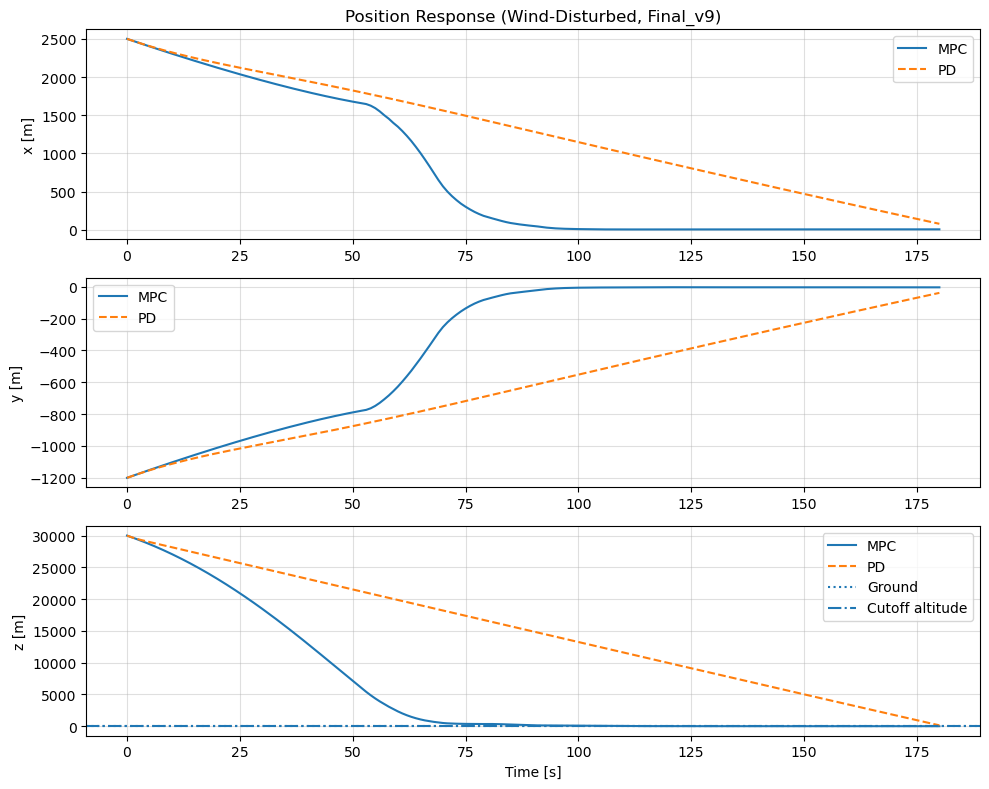

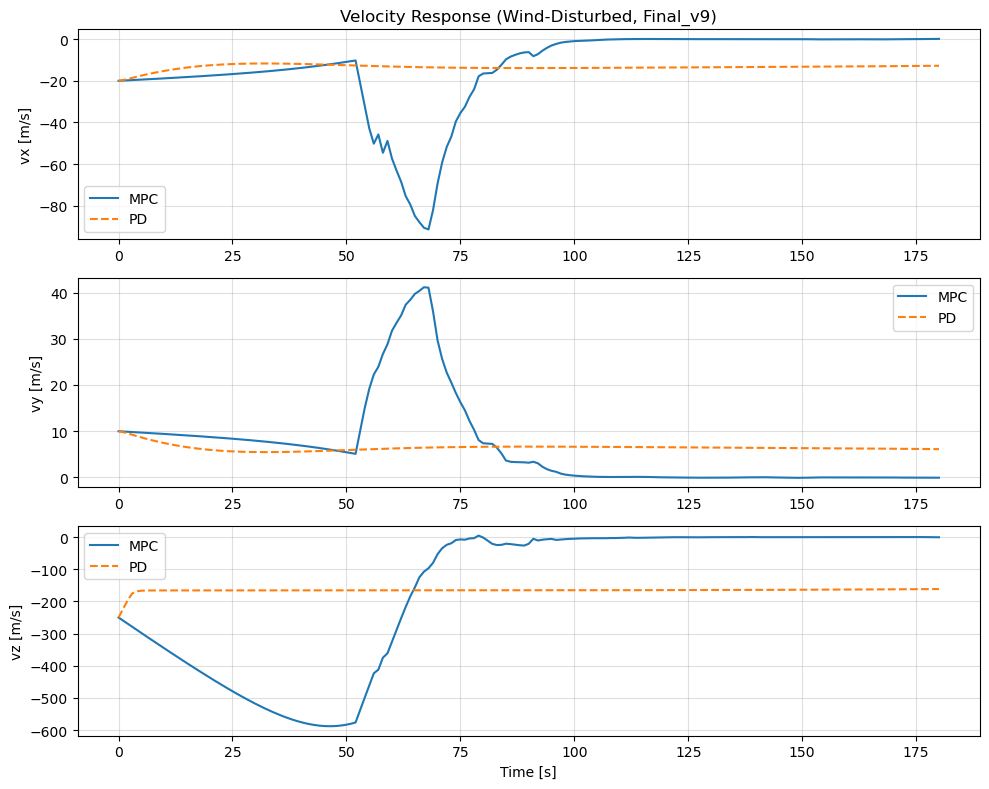

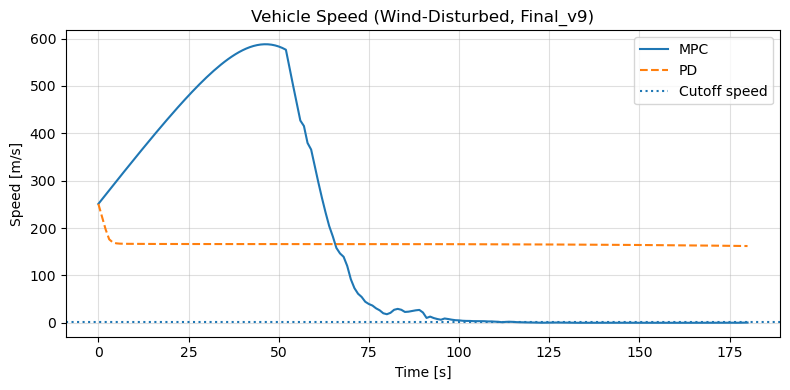

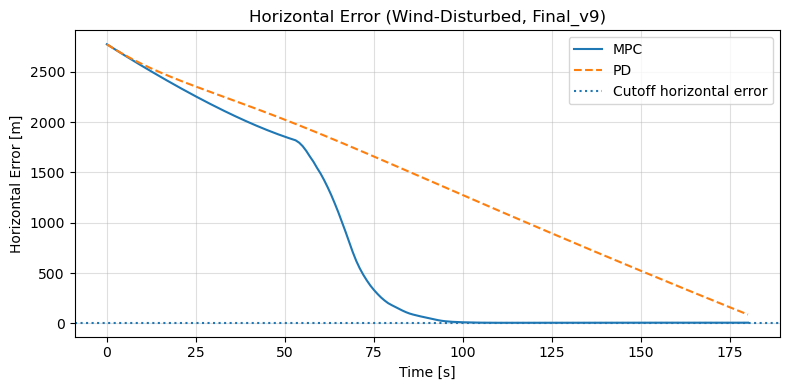

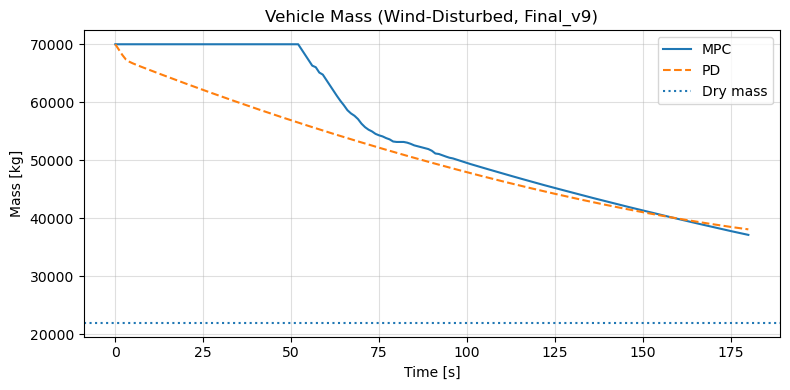

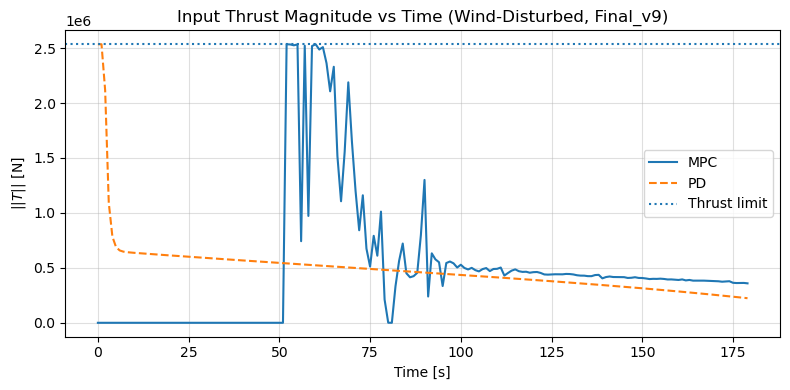

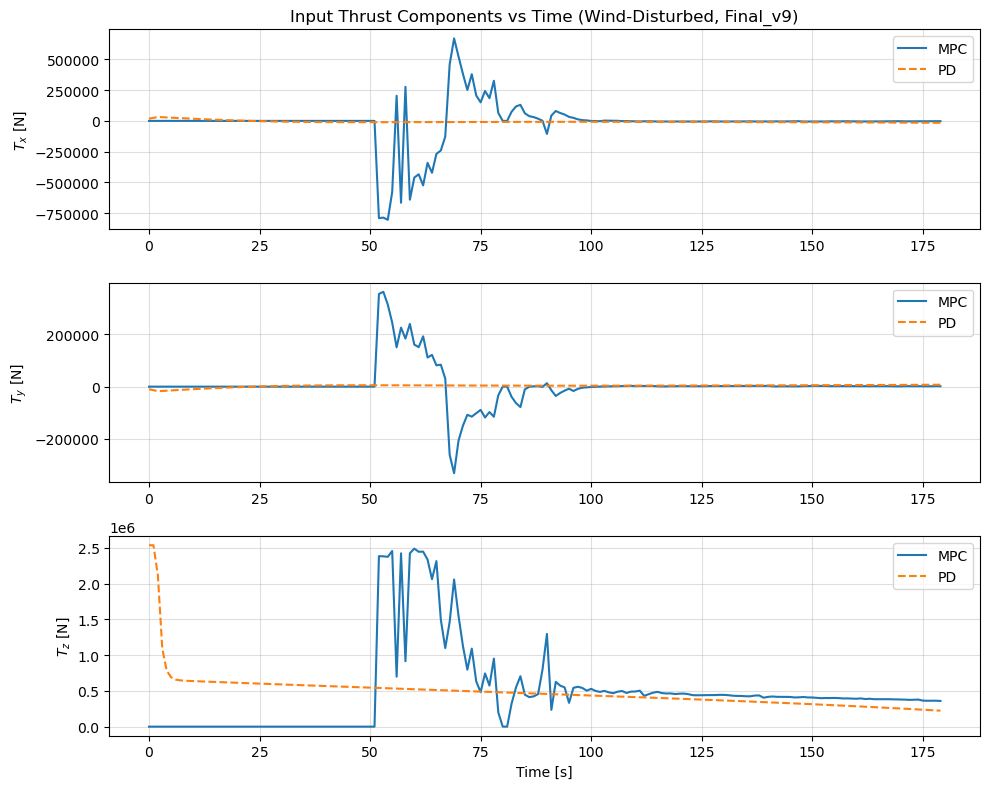

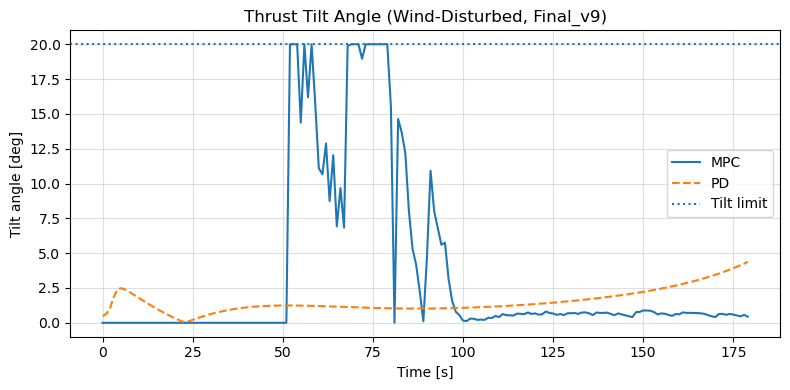

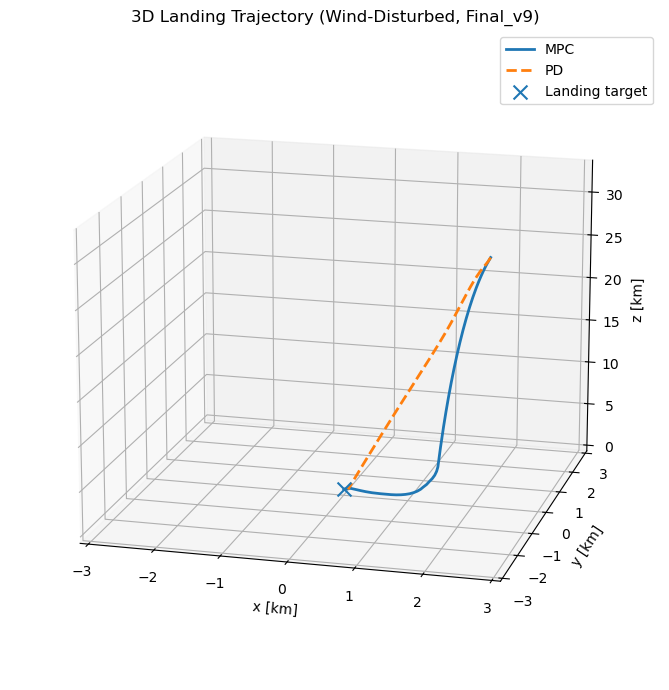

In [1]:
# rocket landing model
# 3d point-mass booster descent with constrained mpc


#NOTE: this solver optimizes the outcome of each case. These optimizations can vary between runs, despite the same weights.
#       This solver averages a nominal solution at ~155sec. For the 134sec run presented in our paper, do NOT run this code, just 
#       look at the original print from this .ipynb. Otherwise, this code can be run as-is.



import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time

from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

# set up ffmpeg for mp4 saves. if this fails, the code will try gif output later
try:
    import imageio_ffmpeg
    import matplotlib.animation as animation

    ffmpeg_path = imageio_ffmpeg.get_ffmpeg_exe()
    plt.rcParams["animation.ffmpeg_path"] = ffmpeg_path

    print("imageio-ffmpeg path:", ffmpeg_path)
    print("Matplotlib sees FFmpeg:", animation.writers.is_available("ffmpeg"))

except Exception as e:
    print("imageio_ffmpeg setup failed. MP4 saving may not work.")
    print("Reason:", e)


# run settings

SAVE_DATA = True
LOAD_DATA_INSTEAD = False

MAKE_ANIMATIONS = True
SHOW_PLOTS = True

# Run nominal case plus wind-disturbed case
RUN_WIND_CASE = True

# MPC update setting
MPC_UPDATE_STEPS = 1

DATA_FILENAME = "rocket_landing_results.npz"
ANIMATION_NOMINAL_FILENAME = "rocket_landing_nominal.mp4"
ANIMATION_WIND_FILENAME = "rocket_landing_wind.mp4"


# plot and animation view settings

VIEW_ELEV = 15
VIEW_AZIM = -75

scale_3d = 1000.0       # 1000.0 = km, 1.0 = m
unit_label_3d = "km"


# parameters
g = 9.81
g0 = 9.81

# vehicle values
m0 = 70000.0             # initial mass [kg]
m_dry = 22000.0          # dry mass lower bound [kg]
Isp = 280.0              # effective sea-level specific impulse [s]

T_max = 845000.0 * 3     # maximum thrust [N]
tilt_max_deg = 20.0      # maximum thrust tilt from vertical [deg]
tilt_max = np.deg2rad(tilt_max_deg)

# basic atmosphere and drag model
rho0 = 1.225             # sea-level density [kg/m^3]
H_scale = 8500.0         # scale height [m]
CdA = 10.0               # effective drag coefficient times area [m^2]

# mpc setup
dt = 1.0
N = 20
Tp = N * dt

# sim time
tf = 180.0
t_vals = np.arange(0.0, tf + dt, dt)

# Initial state: [x, y, z, vx, vy, vz, m]
x0 = np.array([
    2500.0,      # x position [m]
    -1200.0,     # y position [m]
    30000.0,     # altitude [m]
    -20.0,       # x velocity [m/s]
    10.0,        # y velocity [m/s]
    -250.0,      # vertical velocity [m/s]
    m0           # mass [kg]
])

# target is position and velocity only
x_target = np.zeros(6)

# Cost weights for [x, y, z, vx, vy, vz]
Q = np.diag([
    0.005,    # x position
    0.005,    # y position
    0.03,     # z altitude
    0.25,     # vx
    0.25,     # vy
    3.0       # vz
])

# Terminal cost for final state [0, 0, 0, 0, 0, 0]^T
P = np.diag([
    500.0,     # final x
    500.0,     # final y
    1000.0,    # final z
    1000.0,    # final vx
    1000.0,    # final vy
    3000.0     # final vz
])

# Control, fuel, and constraint penalty weights
R_cmd = 0.05
R_fuel = 0.05
ground_penalty_weight = 1e6
dry_mass_penalty_weight = 1e6

# constant wind acceleration for the disturbed case
# this is acceleration
wind = np.array([0.10, -0.05, 0.0])

# cutoff criteria
USE_ENGINE_CUTOFF = True

CUTOFF_HORIZONTAL_ERROR = 3.0     # [m]
CUTOFF_ALTITUDE = 1.5            # [m]
CUTOFF_SPEED = 1.0               # [m/s]


# thrust utilities

def command_to_thrust(cmd):
    """
    Convert optimizer variables [rho, px, py] into a thrust vector.
    The parameterization keeps thrust within the magnitude and tilt limits.
    """
    rho = np.clip(cmd[0], 0.0, 1.0)
    p = np.array([cmd[1], cmd[2]], dtype=float)

    p_norm = np.linalg.norm(p)

    if p_norm > 1.0:
        p = p / p_norm

    lateral_frac = np.sin(tilt_max) * p
    lateral_frac_norm = np.linalg.norm(lateral_frac)

    vertical_frac = np.sqrt(max(0.0, 1.0 - lateral_frac_norm**2))

    direction = np.array([
        lateral_frac[0],
        lateral_frac[1],
        vertical_frac
    ])

    T = T_max * rho * direction

    return T


def sequence_to_thrust(U_cmd):
    # turn a whole horizon of command variables into thrust vectors
    U_cmd = U_cmd.reshape(N, 3)
    T_seq = np.zeros((N, 3))

    for k in range(N):
        T_seq[k] = command_to_thrust(U_cmd[k])

    return T_seq


def enforce_thrust_limits(T):
    # projection used by the pd controller
    T = T.copy()

    # No downward thrust
    T[2] = max(T[2], 0.0)

    # Enforce tilt cone
    lateral = np.linalg.norm(T[0:2])
    lateral_max = T[2] * np.tan(tilt_max)

    if lateral > lateral_max and lateral > 1e-9:
        T[0:2] *= lateral_max / lateral

    # Enforce max thrust
    T_mag = np.linalg.norm(T)

    if T_mag > T_max and T_mag > 1e-9:
        T *= T_max / T_mag

    return T


def limit_thrust_by_fuel(T, m, dt):
    # keeps the vehicle from burning below dry mass in one step
    T = T.copy()

    fuel_available = max(0.0, m - m_dry)

    if fuel_available <= 0.0:
        return np.zeros(3)

    T_fuel_limit = fuel_available * Isp * g0 / dt
    T_mag = np.linalg.norm(T)

    if T_mag > T_fuel_limit and T_mag > 1e-9:
        T *= T_fuel_limit / T_mag

    return T


# dynamics
def air_density(z):
    # exponential atmosphere
    z = max(z, 0.0)
    return rho0 * np.exp(-z / H_scale)


def drag_acceleration(x):
    # drag acts opposite the velocity vector
    z = x[2]
    v = x[3:6]
    m = x[6]

    v_norm = np.linalg.norm(v)

    if v_norm < 1e-9:
        return np.zeros(3)

    rho = air_density(z)
    a_drag = -0.5 * rho * CdA * v_norm * v / m

    return a_drag


def rocket_dynamics(x, T, wind_accel=np.zeros(3)):
    # state derivative for the point-mass booster model
    rx, ry, rz, vx, vy, vz, m = x
    Tx, Ty, Tz = T

    T_mag = np.linalg.norm(T)
    a_drag = drag_acceleration(x)

    xdot = np.array([
        vx,
        vy,
        vz,
        Tx / m + a_drag[0] + wind_accel[0],
        Ty / m + a_drag[1] + wind_accel[1],
        Tz / m - g + a_drag[2] + wind_accel[2],
        -T_mag / (Isp * g0)
    ])

    return xdot


def step_dynamics(x, T, dt, wind_accel=np.zeros(3)):
    # one forward euler step
    T_use = limit_thrust_by_fuel(T, x[6], dt)

    x_next = x + dt * rocket_dynamics(x, T_use, wind_accel)

    # Numerical safety
    x_next[6] = max(x_next[6], m_dry)

    return x_next


def touchdown_step(x_current, x_next):
    # if the trajectory crosses z=0, interpolate to the ground
    z0 = x_current[2]
    z1 = x_next[2]

    if z1 >= 0.0:
        return x_next, False

    if z0 <= 0.0:
        x_touch = x_current.copy()
        x_touch[2] = 0.0
        return x_touch, True

    alpha = z0 / (z0 - z1)
    x_touch = x_current + alpha * (x_next - x_current)
    x_touch[2] = 0.0

    return x_touch, True


# MPC
def predict_trajectory(x_current, U_cmd_flat):
    # prediction model
    
    X = np.zeros((N + 1, 7))
    T_seq = sequence_to_thrust(U_cmd_flat)

    X[0] = x_current.copy()

    for k in range(N):
        X[k + 1] = step_dynamics(
            X[k],
            T_seq[k],
            dt,
            wind_accel=np.zeros(3)
        )

    return X, T_seq


def mpc_cost(U_cmd_flat, x_current):
    # finite-horizon objective for state tracking, control effort, and fuel use
    X, T_seq = predict_trajectory(x_current, U_cmd_flat)
    U_cmd = U_cmd_flat.reshape(N, 3)

    J = 0.0

    for k in range(N):
        e = X[k, 0:6] - x_target
        cmd = U_cmd[k]

        rho = cmd[0]

        J += dt * (
            e @ Q @ e
            + R_cmd * (cmd @ cmd)
            + R_fuel * rho**2
        )

        # Soft ground penalty
        if X[k, 2] < 0.0:
            J += ground_penalty_weight * X[k, 2]**2

        # Dry mass penalty
        if X[k, 6] < m_dry:
            J += dry_mass_penalty_weight * (m_dry - X[k, 6])**2

    # Terminal landing error
    e_final = X[-1, 0:6] - x_target
    J += e_final @ P @ e_final

    if X[-1, 2] < 0.0:
        J += ground_penalty_weight * X[-1, 2]**2

    if X[-1, 6] < m_dry:
        J += dry_mass_penalty_weight * (m_dry - X[-1, 6])**2

    return J


def solve_mpc(x_current, U_guess):
    # solve the bounded horizon problem
    bounds = []

    for _ in range(N):
        bounds.append((0.0, 1.0))    # rho
        bounds.append((-1.0, 1.0))   # px
        bounds.append((-1.0, 1.0))   # py

    result = minimize(
        lambda U_flat: mpc_cost(U_flat, x_current),
        U_guess,
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 50,
            "ftol": 1e-4,
            "maxls": 20
        }
    )

    return result.x, result


# PD controller

def pd_controller(x, t):
    # simple reference-following pd controller
    r = x[0:3]
    v = x[3:6]
    m = x[6]

    # Fraction of simulation completed
    s = np.clip(t / tf, 0.0, 1.0)

    # Linear reference from initial position to target
    r_ref = np.array([
        x0[0] * (1.0 - s),
        x0[1] * (1.0 - s),
        x0[2] * (1.0 - s)
    ])

    # Constant reference velocity
    v_ref = np.array([
        -x0[0] / tf,
        -x0[1] / tf,
        -x0[2] / tf
    ])

    # Tuned PD gains
    Kp = np.array([0.004, 0.004, 0.003])
    Kd = np.array([0.08, 0.08, 0.70])

    # Desired acceleration
    a_cmd = (
        Kp * (r_ref - r)
        + Kd * (v_ref - v)
        + np.array([0.0, 0.0, g])
    )

    # Convert acceleration command to thrust
    T = m * a_cmd
    T = enforce_thrust_limits(T)

    return T


# cutoff check
def engine_cutoff_condition(x):

    horizontal_error = np.linalg.norm(x[0:2])
    altitude = x[2]
    speed = np.linalg.norm(x[3:6])

    return (
        horizontal_error <= CUTOFF_HORIZONTAL_ERROR
        and altitude <= CUTOFF_ALTITUDE
        and speed <= CUTOFF_SPEED
    )


# closed-loop simulation
def simulate_controller(controller_type="mpc", wind_accel=np.zeros(3)):

    X_hist = np.zeros((len(t_vals), 7))
    U_hist = np.zeros((len(t_vals) - 1, 3))
    solve_times = []
    success_flags = []

    X_hist[0] = x0.copy()

    # Initial MPC guess: mostly coast at first
    U_guess = np.zeros(3 * N)

    for k in range(N):
        U_guess[3*k:3*k+3] = np.array([0.0, 0.0, 0.0])

    landed = False
    cutoff = False
    T_hold = np.zeros(3)

    for k in range(len(t_vals) - 1):
        x_current = X_hist[k].copy()

        # Stop if already landed
        if landed or x_current[2] <= 0.0:
            X_hist[k:, :] = x_current
            X_hist[k:, 2] = 0.0
            U_hist[k:, :] = 0.0
            break

        # Stop if engine cutoff condition is satisfied
        if USE_ENGINE_CUTOFF and engine_cutoff_condition(x_current):
            cutoff = True

            print(
                f"\nEngine cutoff at t = {t_vals[k]:.1f} s "
                f"for {controller_type.upper()}"
            )

            X_hist[k:, :] = x_current
            U_hist[k:, :] = 0.0
            break

        if controller_type == "mpc":

            if k % MPC_UPDATE_STEPS == 0:
                start = time.time()
                U_star, result = solve_mpc(x_current, U_guess)
                solve_times.append(time.time() - start)
                success_flags.append(result.success)

                T_hold = command_to_thrust(U_star[0:3])

                # Shift command guess for next MPC solve
                U_guess[:-3] = U_star[3:]
                U_guess[-3:] = U_star[-3:]

            T_apply = T_hold

        elif controller_type == "pd":
            T_apply = pd_controller(x_current, t_vals[k])

        else:
            raise ValueError("controller_type must be 'mpc' or 'pd'.")

        # Apply finite-fuel limit to the actual thrust
        T_apply = limit_thrust_by_fuel(T_apply, x_current[6], dt)
        U_hist[k] = T_apply

        x_next_raw = step_dynamics(
            x_current,
            T_apply,
            dt,
            wind_accel=wind_accel
        )

        x_next, landed = touchdown_step(x_current, x_next_raw)
        X_hist[k + 1] = x_next

        if (k + 1) % 10 == 0:
            print(f"{controller_type.upper()} step {k+1}/{len(t_vals)-1}")

    return X_hist, U_hist, np.array(solve_times), np.array(success_flags)


#Metric saving

def compute_tilt_history(U):
    # thrust vector tilt angle from vertical.

    tilt = np.zeros(U.shape[0])

    for k, T in enumerate(U):
        T_mag = np.linalg.norm(T)
        lateral = np.linalg.norm(T[0:2])
        vertical = T[2]

        if T_mag > 1e-9 and vertical > 1e-9:
            tilt[k] = np.rad2deg(np.arctan2(lateral, vertical))
        else:
            tilt[k] = 0.0

    return tilt


def compute_constraint_violations(X, U):
    #constraint violation log
    
    thrust_mag = np.linalg.norm(U, axis=1)
    tilt = compute_tilt_history(U)

    max_thrust_violation = max(0.0, np.max(thrust_mag) - T_max)
    max_tilt_violation = max(0.0, np.max(tilt) - tilt_max_deg)
    ground_violation = max(0.0, -np.min(X[:, 2]))
    mass_violation = max(0.0, m_dry - np.min(X[:, 6]))

    return max_thrust_violation, max_tilt_violation, ground_violation, mass_violation


def compute_metrics(X, U, solve_times, success_flags, label):
    #print all metrics
    
    final_state = X[-1]

    final_pos_error = np.linalg.norm(final_state[0:3])
    final_horizontal_error = np.linalg.norm(final_state[0:2])
    final_altitude = final_state[2]
    final_speed = np.linalg.norm(final_state[3:6])
    cutoff_condition_met = engine_cutoff_condition(final_state)

    fuel_used = X[0, 6] - final_state[6]
    fuel_margin_above_dry = final_state[6] - m_dry
    thrust_integral = np.sum(np.linalg.norm(U, axis=1)) * dt

    thrust_mag = np.linalg.norm(U, axis=1)
    tilt = compute_tilt_history(U)

    max_thrust = np.max(thrust_mag)
    max_tilt = np.max(tilt)
    min_altitude = np.min(X[:, 2])
    min_mass = np.min(X[:, 6])

    max_T_vio, max_tilt_vio, ground_vio, mass_vio = compute_constraint_violations(X, U)

    print("\n" + "=" * 60)
    print(label)
    print("=" * 60)
    print(f"Final position error      = {final_pos_error:.3f} m")
    print(f"Final horizontal error    = {final_horizontal_error:.3f} m")
    print(f"Final altitude            = {final_altitude:.3f} m")
    print(f"Final speed               = {final_speed:.3f} m/s")
    print(f"Cutoff condition met      = {cutoff_condition_met}")
    print(f"Fuel used                 = {fuel_used:.3f} kg")
    print(f"Final mass                = {final_state[6]:.3f} kg")
    print(f"Fuel margin above dry     = {fuel_margin_above_dry:.3f} kg")
    print(f"Thrust integral           = {thrust_integral:.3f} N*s")
    print(f"Max thrust                = {max_thrust:.3f} N")
    print(f"Max tilt angle            = {max_tilt:.3f} deg")
    print(f"Minimum altitude          = {min_altitude:.3f} m")
    print(f"Minimum mass              = {min_mass:.3f} kg")

    print("\nConstraint checks:")
    print(f"Max thrust violation      = {max_T_vio:.6f} N")
    print(f"Max tilt violation        = {max_tilt_vio:.6f} deg")
    print(f"Ground violation          = {ground_vio:.6f} m")
    print(f"Mass violation            = {mass_vio:.6f} kg")

    if len(solve_times) > 0:
        print("\nComputational performance:")
        print(f"Number of MPC solves      = {len(solve_times)}")
        print(f"Mean MPC solve time       = {np.mean(solve_times):.4f} s")
        print(f"Max MPC solve time        = {np.max(solve_times):.4f} s")

        if len(success_flags) > 0:
            success_rate = 100.0 * np.mean(success_flags)
            print(f"MPC optimizer success     = {success_rate:.1f} %")


# saving and loading

def save_simulation_data(filename, data):
    """
    Save simulation data to a .npz file.
    """
    save_dict = {
        # time and parameters
        "t_vals": t_vals,
        "dt": dt,
        "tf": tf,
        "N": N,
        "Tp": Tp,
        "MPC_UPDATE_STEPS": MPC_UPDATE_STEPS,
        "g": g,
        "g0": g0,
        "m0": m0,
        "m_dry": m_dry,
        "Isp": Isp,
        "T_max": T_max,
        "tilt_max_deg": tilt_max_deg,
        "rho0": rho0,
        "H_scale": H_scale,
        "CdA": CdA,
        "x0": x0,
        "x_target": x_target,
        "R_fuel": R_fuel,
        "RUN_WIND_CASE": RUN_WIND_CASE,
        "wind": wind,

        # cutoff parameters
        "USE_ENGINE_CUTOFF": USE_ENGINE_CUTOFF,
        "CUTOFF_HORIZONTAL_ERROR": CUTOFF_HORIZONTAL_ERROR,
        "CUTOFF_ALTITUDE": CUTOFF_ALTITUDE,
        "CUTOFF_SPEED": CUTOFF_SPEED,
    }

    # Add simulation arrays
    save_dict.update(data)

    np.savez(filename, **save_dict)

    print(f"\nSaved simulation data to: {filename}")


def load_simulation_data(filename):
    """
    Load previously saved simulation data.
    """
    loaded = np.load(filename, allow_pickle=True)
    data = {key: loaded[key] for key in loaded.files}

    print(f"\nLoaded simulation data from: {filename}")

    return data


# plotting
def plot_results(X_mpc, U_mpc, X_pd, U_pd, title_suffix=""):

    t = t_vals
    tc = t_vals[:-1]

    # position
    plt.figure(figsize=(10, 8))
    labels = ["x [m]", "y [m]", "z [m]"]

    for i in range(3):
        plt.subplot(3, 1, i + 1)
        plt.plot(t, X_mpc[:, i], label="MPC")
        plt.plot(t, X_pd[:, i], "--", label="PD")
        if i == 2:
            plt.axhline(0.0, linestyle=":", label="Ground")
            plt.axhline(CUTOFF_ALTITUDE, linestyle="-.", label="Cutoff altitude")
        plt.ylabel(labels[i])
        plt.grid(True, alpha=0.4)
        if i == 0:
            plt.title("Position Response " + title_suffix)
        if i == 2:
            plt.xlabel("Time [s]")
        plt.legend()

    plt.tight_layout()

    # velocity
    plt.figure(figsize=(10, 8))
    labels = ["vx [m/s]", "vy [m/s]", "vz [m/s]"]

    for i in range(3):
        plt.subplot(3, 1, i + 1)
        plt.plot(t, X_mpc[:, i + 3], label="MPC")
        plt.plot(t, X_pd[:, i + 3], "--", label="PD")
        plt.ylabel(labels[i])
        plt.grid(True, alpha=0.4)
        if i == 0:
            plt.title("Velocity Response " + title_suffix)
        if i == 2:
            plt.xlabel("Time [s]")
        plt.legend()

    plt.tight_layout()

    # speed
    plt.figure(figsize=(8, 4))
    speed_mpc = np.linalg.norm(X_mpc[:, 3:6], axis=1)
    speed_pd = np.linalg.norm(X_pd[:, 3:6], axis=1)

    plt.plot(t, speed_mpc, label="MPC")
    plt.plot(t, speed_pd, "--", label="PD")
    plt.axhline(CUTOFF_SPEED, linestyle=":", label="Cutoff speed")
    plt.xlabel("Time [s]")
    plt.ylabel("Speed [m/s]")
    plt.title("Vehicle Speed " + title_suffix)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()

    # horizontal error
    plt.figure(figsize=(8, 4))
    horiz_mpc = np.linalg.norm(X_mpc[:, 0:2], axis=1)
    horiz_pd = np.linalg.norm(X_pd[:, 0:2], axis=1)

    plt.plot(t, horiz_mpc, label="MPC")
    plt.plot(t, horiz_pd, "--", label="PD")
    plt.axhline(CUTOFF_HORIZONTAL_ERROR, linestyle=":", label="Cutoff horizontal error")
    plt.xlabel("Time [s]")
    plt.ylabel("Horizontal Error [m]")
    plt.title("Horizontal Error " + title_suffix)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()

    # mass
    plt.figure(figsize=(8, 4))
    plt.plot(t, X_mpc[:, 6], label="MPC")
    plt.plot(t, X_pd[:, 6], "--", label="PD")
    plt.axhline(m_dry, linestyle=":", label="Dry mass")
    plt.xlabel("Time [s]")
    plt.ylabel("Mass [kg]")
    plt.title("Vehicle Mass " + title_suffix)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()

    # thrust magnitude
    plt.figure(figsize=(8, 4))
    plt.plot(tc, np.linalg.norm(U_mpc, axis=1), label="MPC")
    plt.plot(tc, np.linalg.norm(U_pd, axis=1), "--", label="PD")
    plt.axhline(T_max, linestyle=":", label="Thrust limit")
    plt.xlabel("Time [s]")
    plt.ylabel(r"$||T||$ [N]")
    plt.title("Input Thrust Magnitude vs Time " + title_suffix)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()

    # thrust components
    plt.figure(figsize=(10, 8))
    thrust_labels = [r"$T_x$ [N]", r"$T_y$ [N]", r"$T_z$ [N]"]

    for i in range(3):
        plt.subplot(3, 1, i + 1)
        plt.plot(tc, U_mpc[:, i], label="MPC")
        plt.plot(tc, U_pd[:, i], "--", label="PD")
        plt.ylabel(thrust_labels[i])
        plt.grid(True, alpha=0.4)
        if i == 0:
            plt.title("Input Thrust Components vs Time " + title_suffix)
        if i == 2:
            plt.xlabel("Time [s]")
        plt.legend()

    plt.tight_layout()

    # tilt
    tilt_mpc = compute_tilt_history(U_mpc)
    tilt_pd = compute_tilt_history(U_pd)

    plt.figure(figsize=(8, 4))
    plt.plot(tc, tilt_mpc, label="MPC")
    plt.plot(tc, tilt_pd, "--", label="PD")
    plt.axhline(tilt_max_deg, linestyle=":", label="Tilt limit")
    plt.xlabel("Time [s]")
    plt.ylabel("Tilt angle [deg]")
    plt.title("Thrust Tilt Angle " + title_suffix)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()

    # 3d path
    x_mpc = X_mpc[:, 0] / scale_3d
    y_mpc = X_mpc[:, 1] / scale_3d
    z_mpc = X_mpc[:, 2] / scale_3d

    x_pd = X_pd[:, 0] / scale_3d
    y_pd = X_pd[:, 1] / scale_3d
    z_pd = X_pd[:, 2] / scale_3d

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

    ax.plot(x_mpc, y_mpc, z_mpc, label="MPC", linewidth=2)
    ax.plot(x_pd, y_pd, z_pd, "--", label="PD", linewidth=2)
    ax.scatter([0], [0], [0], marker="x", s=100, label="Landing target")

    ax.set_xlabel(f"x [{unit_label_3d}]")
    ax.set_ylabel(f"y [{unit_label_3d}]")
    ax.set_zlabel(f"z [{unit_label_3d}]")
    ax.set_title("3D Landing Trajectory " + title_suffix)

    x_all = np.concatenate([x_mpc, x_pd, np.array([0.0])])
    y_all = np.concatenate([y_mpc, y_pd, np.array([0.0])])
    z_all = np.concatenate([z_mpc, z_pd, np.array([0.0])])

    z_min, z_max = np.min(z_all), np.max(z_all)
    z_pad = 0.1 * max(1.0, z_max - z_min)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(max(0.0, z_min - z_pad), z_max + z_pad)

    ax.legend()
    plt.tight_layout()



# animation

def save_animation(X_mpc, U_mpc, X_pd, U_pd, filename, title):

    print(f"\nCreating animation: {filename}")

    x_mpc = X_mpc[:, 0] / scale_3d
    y_mpc = X_mpc[:, 1] / scale_3d
    z_mpc = X_mpc[:, 2] / scale_3d

    x_pd = X_pd[:, 0] / scale_3d
    y_pd = X_pd[:, 1] / scale_3d
    z_pd = X_pd[:, 2] / scale_3d

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

    ax.set_xlabel(f"x [{unit_label_3d}]")
    ax.set_ylabel(f"y [{unit_label_3d}]")
    ax.set_zlabel(f"z [{unit_label_3d}]")
    ax.set_title(title)

    ax.plot(x_mpc, y_mpc, z_mpc, alpha=0.25, label="MPC path")
    ax.plot(x_pd, y_pd, z_pd, "--", alpha=0.25, label="PD path")
    ax.scatter([0], [0], [0], marker="x", s=100, label="Target")

    z_min = min(np.min(z_mpc), np.min(z_pd), 0.0)
    z_max = max(np.max(z_mpc), np.max(z_pd), 0.0)
    z_pad = 0.1 * max(1.0, z_max - z_min)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(max(0.0, z_min - z_pad), z_max + z_pad)

    mpc_trace, = ax.plot([], [], [], linewidth=2, label="MPC")
    pd_trace, = ax.plot([], [], [], "--", linewidth=2, label="PD")

    mpc_point, = ax.plot([], [], [], marker="o", markersize=8)
    pd_point, = ax.plot([], [], [], marker="s", markersize=7)

    mpc_quiver = [None]
    pd_quiver = [None]

    time_text = ax.text2D(0.05, 0.95, "", transform=ax.transAxes)

    ax.legend(loc="upper right")

    frame_step = 2
    frames = range(0, len(t_vals), frame_step)

    def update(frame):
        k = frame

        mpc_trace.set_data(x_mpc[:k+1], y_mpc[:k+1])
        mpc_trace.set_3d_properties(z_mpc[:k+1])

        pd_trace.set_data(x_pd[:k+1], y_pd[:k+1])
        pd_trace.set_3d_properties(z_pd[:k+1])

        mpc_point.set_data([x_mpc[k]], [y_mpc[k]])
        mpc_point.set_3d_properties([z_mpc[k]])

        pd_point.set_data([x_pd[k]], [y_pd[k]])
        pd_point.set_3d_properties([z_pd[k]])

        if mpc_quiver[0] is not None:
            mpc_quiver[0].remove()

        if pd_quiver[0] is not None:
            pd_quiver[0].remove()

        if k < len(U_mpc):
            arrow_scale = 0.05 * np.max(X_mpc[:, 2]) / T_max / scale_3d

            Tm = U_mpc[k] * arrow_scale
            Tp = U_pd[k] * arrow_scale

            mpc_quiver[0] = ax.quiver(
                x_mpc[k], y_mpc[k], z_mpc[k],
                Tm[0], Tm[1], Tm[2],
                length=1.0,
                normalize=False
            )

            pd_quiver[0] = ax.quiver(
                x_pd[k], y_pd[k], z_pd[k],
                Tp[0], Tp[1], Tp[2],
                length=1.0,
                normalize=False
            )

        time_text.set_text(f"t = {t_vals[k]:.1f} s")

        return mpc_trace, pd_trace, mpc_point, pd_point, time_text

    anim = FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=80,
        blit=False
    )

    try:
        writer = FFMpegWriter(fps=12, bitrate=1800)
        anim.save(filename, writer=writer)
        print(f"Saved MP4 animation to: {filename}")

    except Exception as e:
        gif_name = filename.replace(".mp4", ".gif")
        print("MP4 save failed. Saving GIF instead.")
        print("Reason:", e)
        writer = PillowWriter(fps=12)
        anim.save(gif_name, writer=writer)
        print(f"Saved GIF animation to: {gif_name}")

    plt.close(fig)


# main script

if LOAD_DATA_INSTEAD:
    data = load_simulation_data(DATA_FILENAME)

    X_mpc = data["X_mpc"]
    U_mpc = data["U_mpc"]
    solve_times_mpc = data["solve_times_mpc"]
    success_mpc = data["success_mpc"]

    X_pd = data["X_pd"]
    U_pd = data["U_pd"]

    # Load wind case if it exists in the saved file
    if RUN_WIND_CASE and "X_mpc_wind" in data:
        X_mpc_wind = data["X_mpc_wind"]
        U_mpc_wind = data["U_mpc_wind"]
        solve_times_mpc_wind = data["solve_times_mpc_wind"]
        success_mpc_wind = data["success_mpc_wind"]

        X_pd_wind = data["X_pd_wind"]
        U_pd_wind = data["U_pd_wind"]

    elif RUN_WIND_CASE:
        print("\nWarning: RUN_WIND_CASE is True, but no wind case was found in the saved data.")
        print("Set LOAD_DATA_INSTEAD = False to generate new wind-case data.")
        RUN_WIND_CASE = False

else:
    print("\nRunning nominal MPC simulation...")
    X_mpc, U_mpc, solve_times_mpc, success_mpc = simulate_controller(
        controller_type="mpc",
        wind_accel=np.zeros(3)
    )

    print("\nRunning nominal PD simulation...")
    X_pd, U_pd, solve_times_pd, success_pd = simulate_controller(
        controller_type="pd",
        wind_accel=np.zeros(3)
    )

    data_to_save = {
        "X_mpc": X_mpc,
        "U_mpc": U_mpc,
        "solve_times_mpc": solve_times_mpc,
        "success_mpc": success_mpc,

        "X_pd": X_pd,
        "U_pd": U_pd
    }

    if RUN_WIND_CASE:
        print("\nRunning wind-disturbed MPC simulation...")
        X_mpc_wind, U_mpc_wind, solve_times_mpc_wind, success_mpc_wind = simulate_controller(
            controller_type="mpc",
            wind_accel=wind
        )

        print("\nRunning wind-disturbed PD simulation...")
        X_pd_wind, U_pd_wind, solve_times_pd_wind, success_pd_wind = simulate_controller(
            controller_type="pd",
            wind_accel=wind
        )

        data_to_save.update({
            "X_mpc_wind": X_mpc_wind,
            "U_mpc_wind": U_mpc_wind,
            "solve_times_mpc_wind": solve_times_mpc_wind,
            "success_mpc_wind": success_mpc_wind,

            "X_pd_wind": X_pd_wind,
            "U_pd_wind": U_pd_wind
        })

    if SAVE_DATA:
        save_simulation_data(DATA_FILENAME, data_to_save)


# results

compute_metrics(
    X_mpc,
    U_mpc,
    solve_times_mpc,
    success_mpc,
    "Nominal MPC"
)

compute_metrics(
    X_pd,
    U_pd,
    np.array([]),
    np.array([]),
    "Nominal PD Baseline"
)

if RUN_WIND_CASE:
    compute_metrics(
        X_mpc_wind,
        U_mpc_wind,
        solve_times_mpc_wind,
        success_mpc_wind,
        "Wind-Disturbed MPC"
    )

    compute_metrics(
        X_pd_wind,
        U_pd_wind,
        np.array([]),
        np.array([]),
        "Wind-Disturbed PD Baseline"
    )


# plots

plot_results(
    X_mpc,
    U_mpc,
    X_pd,
    U_pd,
    title_suffix="(Nominal)"
)

if RUN_WIND_CASE:
    plot_results(
        X_mpc_wind,
        U_mpc_wind,
        X_pd_wind,
        U_pd_wind,
        title_suffix="(Wind-Disturbed)"
    )


# animations

if MAKE_ANIMATIONS:
    save_animation(
        X_mpc,
        U_mpc,
        X_pd,
        U_pd,
        ANIMATION_NOMINAL_FILENAME,
        "Rocket Landing: Nominal Case"
    )

    if RUN_WIND_CASE:
        save_animation(
            X_mpc_wind,
            U_mpc_wind,
            X_pd_wind,
            U_pd_wind,
            ANIMATION_WIND_FILENAME,
            "Rocket Landing: Wind-Disturbed Case"
        )


if SHOW_PLOTS:
    plt.show()
else:
    plt.close("all")